In [ ]:
import pandas as pd
import matplotlib.pyplot as pltimport numpy as np
import numpy as np

In [26]:
df = pd.read_csv('../Processed_Data/child_period_panel_BEST.csv')
with pd.option_context('display.max_columns', None):
    print(df.head())

      id  period  MPUBID_XRND  CRACE_XRND  CSEX_XRND  CYRB_XRND  \
0  201.0      -1          2.0         3.0        2.0     1993.0   
1  201.0       0          2.0         3.0        2.0     1993.0   
2  201.0       1          2.0         3.0        2.0     1993.0   
3  201.0       2          2.0         3.0        2.0     1993.0   
4  201.0       3          2.0         3.0        2.0     1993.0   

   HGC_OF_MOTHER_AS_OF_MAY_1_R  HOW_MANY_BOOKS  HOW_OFTEN_MOM_READS  \
0                         12.0             NaN                  NaN   
1                         12.0            20.0                  7.0   
2                         12.0            20.0                  5.5   
3                         12.0            20.0                  NaN   
4                         12.0            20.0                  NaN   

   HOW_OFT_CH_EATS_W  MOM_HELPS_CH_LEARN_NUMBERS  MOM_HELPS_CH_LEARN_ALPHABET  \
0                NaN                         NaN                          NaN   
1       

In [27]:
filtered_df = df[['LABOR_INCOME', 'TRANSFER_INCOME']]

#drop rows where labor income is NaN
filtered_df = filtered_df.dropna(subset=['LABOR_INCOME'])

#replace NaN in transfer income with 0
filtered_df['TRANSFER_INCOME'] = filtered_df['TRANSFER_INCOME'].fillna(0)

#alt
# filtered_df = filtered_df.dropna(subset=['TRANSFER_INCOME'])
# filtered_df = filtered_df[filtered_df['LABOR_INCOME'] <= 80000]



#get rid of all observations with transfer income > 80000
filtered_df = filtered_df[filtered_df['TRANSFER_INCOME'] <= 80000]

filtered_df.head()

,LABOR_INCOME,TRANSFER_INCOME
0,43785.857429,0.0
1,8558.784235,0.0
2,0.000000,0.0
3,7831.772116,0.0
4,30717.602061,0.0


/var/folders/w4/8bdyf7817wzghq2ypzxtqpcm0000gn/T/ipykernel_10229/172332347.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_transfer_per_bin = filtered_df.groupby('income_bin')['TRANSFER_INCOME'].mean().reindex(bin_labels)
/var/folders/w4/8bdyf7817wzghq2ypzxtqpcm0000gn/T/ipykernel_10229/172332347.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_labor_per_bin = filtered_df.groupby('income_bin')['LABOR_INCOME'].mean().reindex(bin_labels)


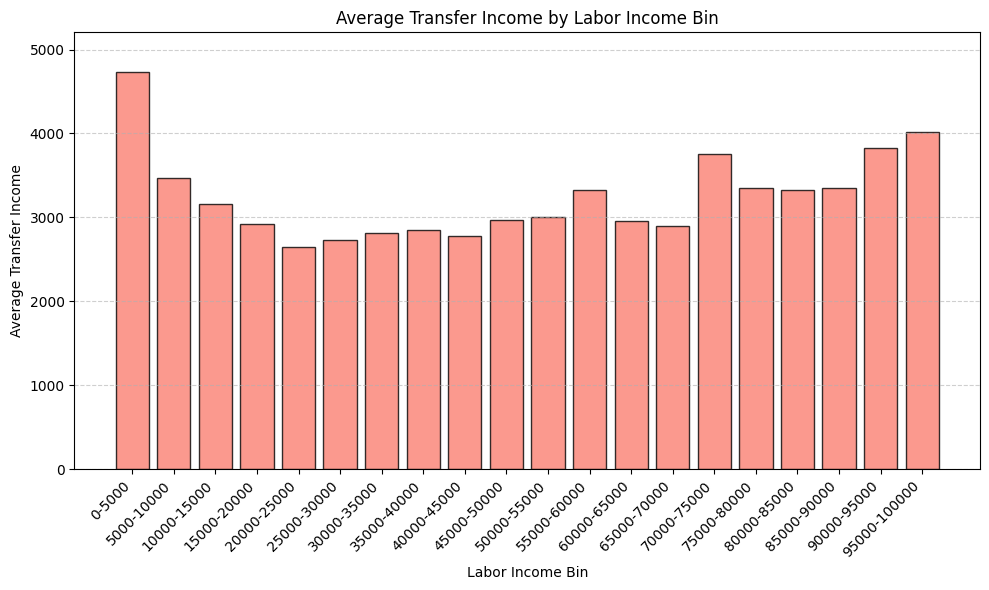

In [ ]:
# Plot average labor income and transfer income per labor income bin

# Define bins
bins = np.arange(0, 100001, 5000)
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

# Assign each row to a bin
filtered_df['income_bin'] = pd.cut(filtered_df['LABOR_INCOME'], bins=bins, labels=bin_labels, right=False, include_lowest=True)

# Calculate average transfer income and average labor income per bin
avg_transfer_per_bin = filtered_df.groupby('income_bin')['TRANSFER_INCOME'].mean().reindex(bin_labels)
avg_labor_per_bin = filtered_df.groupby('income_bin')['LABOR_INCOME'].mean().reindex(bin_labels)

# Plot average transfer income per bin as a bar plot
plt.figure(figsize=(10, 6))
plt.bar(bin_labels, avg_transfer_per_bin, color='salmon', edgecolor='black', alpha=0.8)
plt.xlabel('Labor Income Bin')
plt.ylabel('Average Transfer Income')
plt.title('Average Transfer Income by Labor Income Bin')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, avg_transfer_per_bin.max() * 1.1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


/var/folders/w4/8bdyf7817wzghq2ypzxtqpcm0000gn/T/ipykernel_10229/2736555801.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_transfer_per_bin = filtered_df.groupby('income_bin')['TRANSFER_INCOME'].median().reindex(bin_labels)


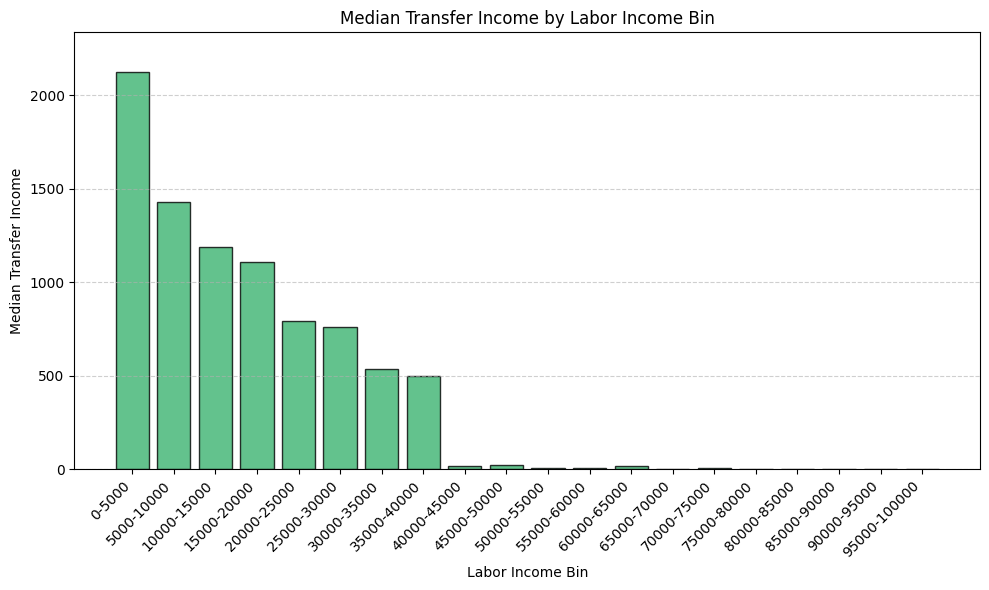

In [43]:
# Calculate median transfer income per labor income bin
median_transfer_per_bin = filtered_df.groupby('income_bin')['TRANSFER_INCOME'].median().reindex(bin_labels)

# Plot median transfer income per bin as a bar plot
plt.figure(figsize=(10, 6))
plt.bar(bin_labels, median_transfer_per_bin, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Labor Income Bin')
plt.ylabel('Median Transfer Income')
plt.title('Median Transfer Income by Labor Income Bin')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, median_transfer_per_bin.max() * 1.1)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


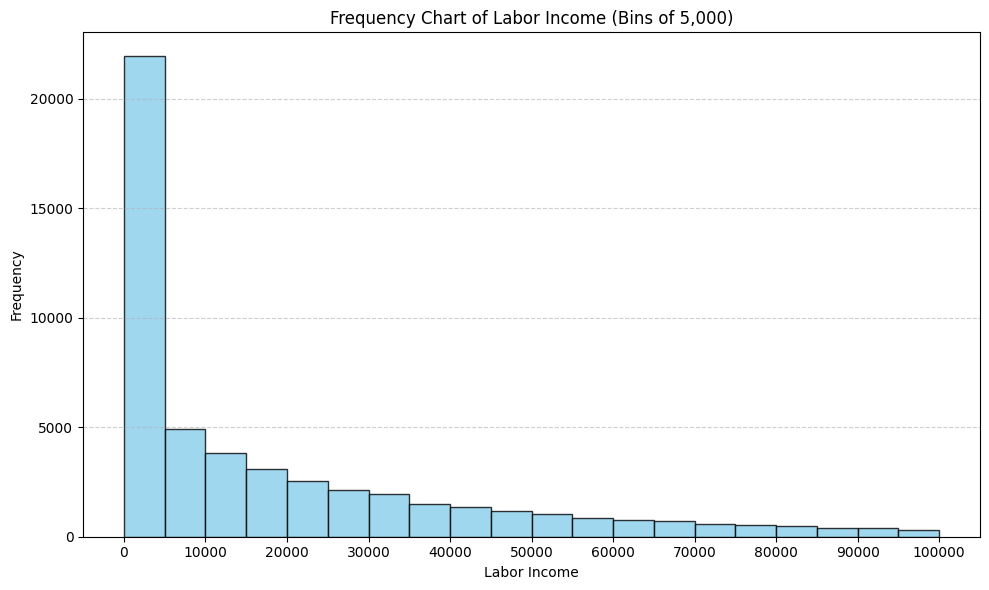

In [42]:
# Plot a frequency chart (histogram) of labor income from 0 to 100,000 with bins of 5,000

plt.figure(figsize=(10, 6))
plt.hist(filtered_df['LABOR_INCOME'], bins=np.arange(0, 100001, 5000), color='skyblue', edgecolor='black', alpha=0.8)
plt.xlabel('Labor Income')
plt.ylabel('Frequency')
plt.title('Frequency Chart of Labor Income (Bins of 5,000)')
plt.xticks(np.arange(0, 100001, 10000))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



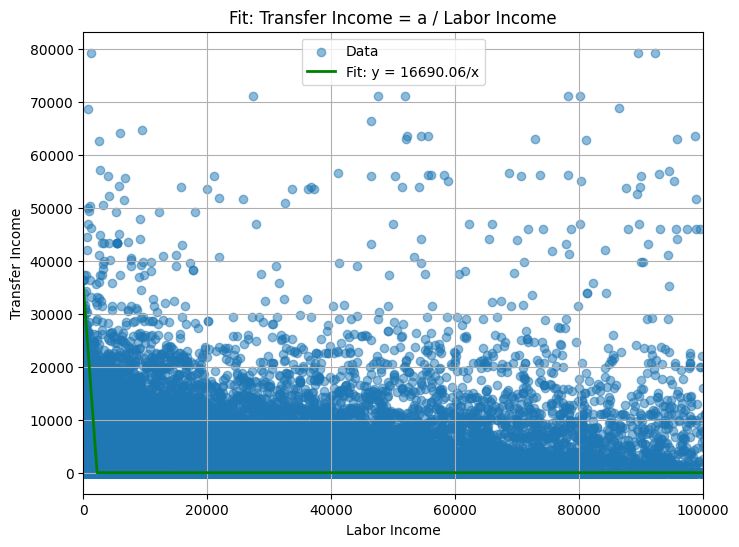

Fitted parameter: a = 16690.061


In [28]:
# Fit y = a * x^-1 to the data (i.e., y = a / x)
from scipy.optimize import curve_fit

def inv_func(x, a):
    return a / x



# Remove zero or negative x values to avoid division by zero
inv_df = filtered_df[filtered_df['LABOR_INCOME'] > 0]
x_inv = inv_df['LABOR_INCOME'].values
y_inv = inv_df['TRANSFER_INCOME'].values

# Fit the model
popt, pcov = curve_fit(inv_func, x_inv, y_inv)
a_fit = popt[0]

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(x_inv, y_inv, alpha=0.5, label='Data')
x_fit = np.linspace(x_inv.min(), x_inv.max(), 500)
plt.plot(x_fit, inv_func(x_fit, a_fit), color='green', linewidth=2, label=f'Fit: y = {a_fit:.2f}/x')
plt.xlabel('Labor Income')
plt.ylabel('Transfer Income')
plt.title('Fit: Transfer Income = a / Labor Income')
plt.xlim(0, 100000)
plt.grid(True)
plt.legend()
plt.show()

print(f"Fitted parameter: a = {a_fit:.3f}")


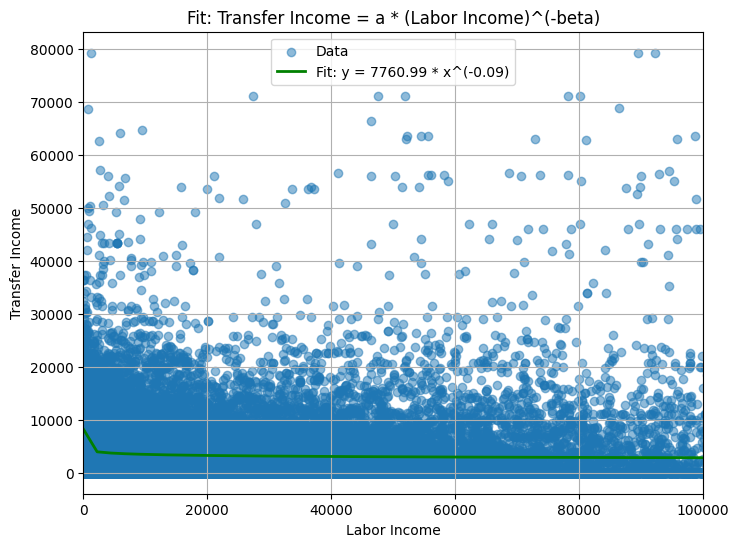

Fitted parameters: a = 7760.993, beta = 0.088


In [34]:
# Fit y = a * x^-beta to the data, where 0 < beta < 1
from scipy.optimize import curve_fit

def inv_power_func(x, a, beta):
    return a * x**(-beta)

# Remove zero or negative x values to avoid division by zero or invalid powers
inv_df = filtered_df[filtered_df['LABOR_INCOME'] > 0]
x_inv = inv_df['LABOR_INCOME'].values
y_inv = inv_df['TRANSFER_INCOME'].values

# Fit the model, constrain beta to (0, 1)
popt, pcov = curve_fit(
    inv_power_func, x_inv, y_inv, 
    bounds=([0, 0], [np.inf, 1])
)
a_fit, beta_fit = popt

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(x_inv, y_inv, alpha=0.5, label='Data')
x_fit = np.linspace(x_inv.min(), x_inv.max(), 500)
plt.plot(x_fit, inv_power_func(x_fit, a_fit, beta_fit), color='green', linewidth=2, 
         label=f'Fit: y = {a_fit:.2f} * x^(-{beta_fit:.2f})')
plt.xlabel('Labor Income')
plt.ylabel('Transfer Income')
plt.title('Fit: Transfer Income = a * (Labor Income)^(-beta)')
plt.xlim(0, 100000)
plt.grid(True)
plt.legend()
plt.show()

print(f"Fitted parameters: a = {a_fit:.3f}, beta = {beta_fit:.3f}")


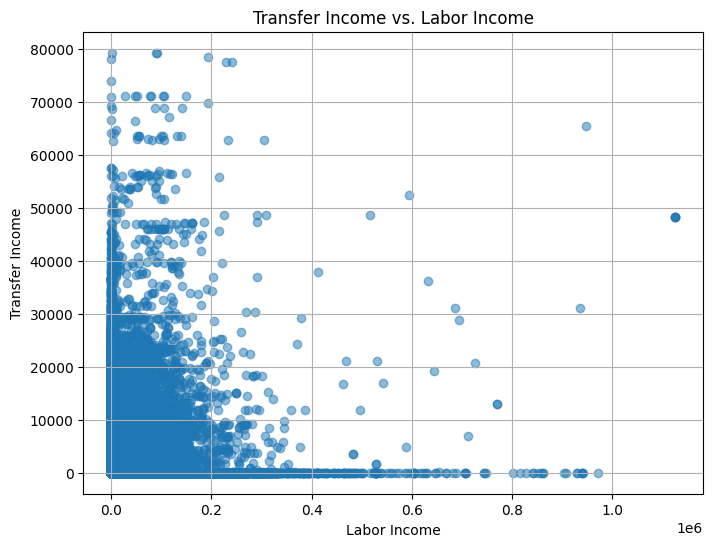

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['LABOR_INCOME'], filtered_df['TRANSFER_INCOME'], alpha=0.5)
plt.xlabel('Labor Income')
plt.ylabel('Transfer Income')
plt.title('Transfer Income vs. Labor Income')
plt.grid(True)
plt.show()


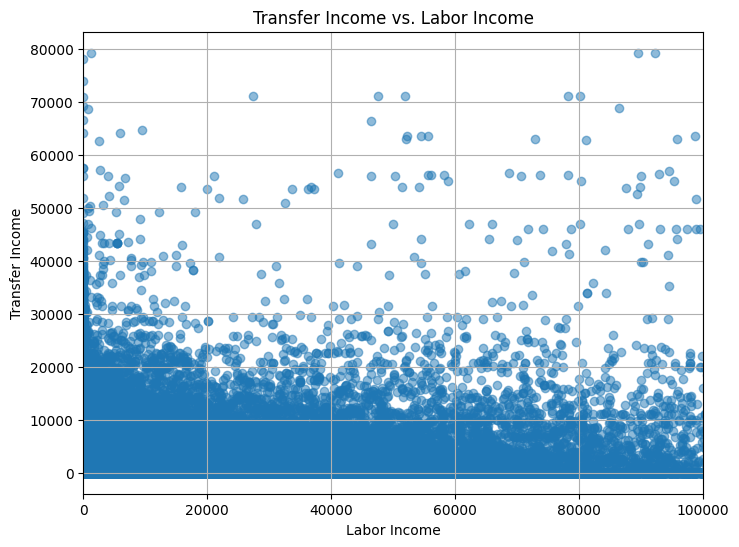

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['LABOR_INCOME'], filtered_df['TRANSFER_INCOME'], alpha=0.5)
plt.xlabel('Labor Income')
plt.ylabel('Transfer Income')
plt.title('Transfer Income vs. Labor Income')
plt.xlim(0, 100000)
plt.grid(True)
plt.show()


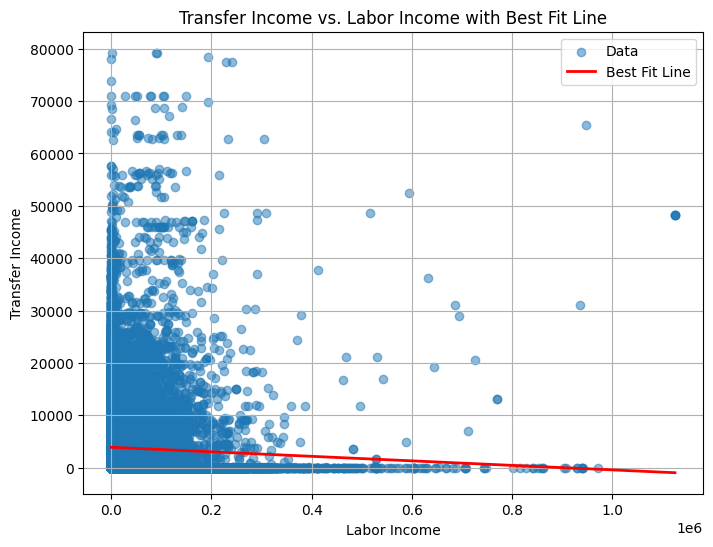

In [31]:
import numpy as np

# Calculate line of best fit
x = filtered_df['LABOR_INCOME']
y = filtered_df['TRANSFER_INCOME']
coeffs = np.polyfit(x, y, 1)
line = np.poly1d(coeffs)

# Plot scatter and line of best fit
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.5, label='Data')
plt.plot(np.sort(x), line(np.sort(x)), color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('Labor Income')
plt.ylabel('Transfer Income')
plt.title('Transfer Income vs. Labor Income with Best Fit Line')
plt.grid(True)
plt.legend()
plt.show()


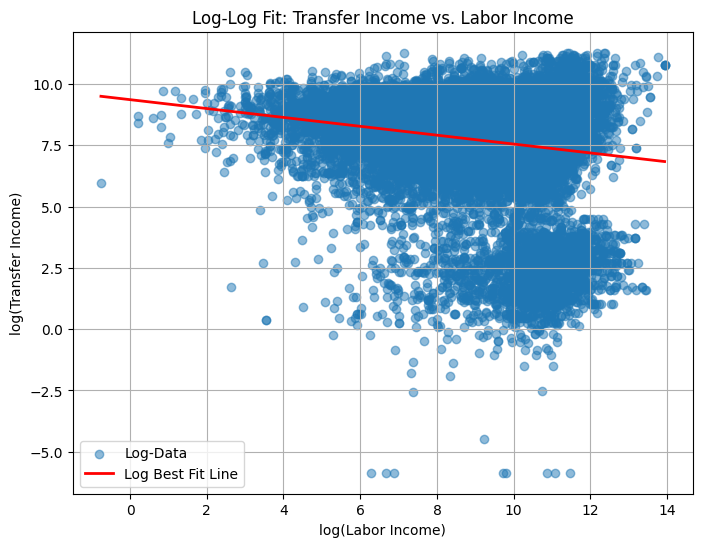

log(Transfer Income) = -0.181 * log(Labor Income) + 9.365


In [32]:
# Log-log fit and plot

# Remove non-positive values to avoid log(0) or log(negative)
log_df = filtered_df[(filtered_df['LABOR_INCOME'] > 0) & (filtered_df['TRANSFER_INCOME'] > 0)]

x_log = np.log(log_df['LABOR_INCOME'])
y_log = np.log(log_df['TRANSFER_INCOME'])

# Fit line in log-log space
log_coeffs = np.polyfit(x_log, y_log, 1)
log_line = np.poly1d(log_coeffs)

# Plot in log-log space
plt.figure(figsize=(8, 6))
plt.scatter(x_log, y_log, alpha=0.5, label='Log-Data')
plt.plot(np.sort(x_log), log_line(np.sort(x_log)), color='red', linewidth=2, label='Log Best Fit Line')
plt.xlabel('log(Labor Income)')
plt.ylabel('log(Transfer Income)')
plt.title('Log-Log Fit: Transfer Income vs. Labor Income')
plt.grid(True)
plt.legend()
plt.show()

# Optionally, print the equation of the fit
print(f"log(Transfer Income) = {log_coeffs[0]:.3f} * log(Labor Income) + {log_coeffs[1]:.3f}")


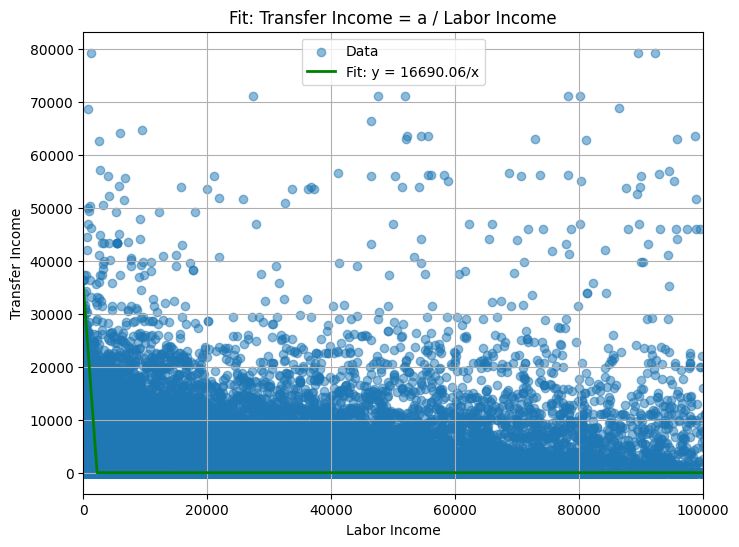

Fitted parameter: a = 16690.061


In [33]:
# Fit y = a * x^-1 to the data (i.e., y = a / x)
from scipy.optimize import curve_fit

def inv_func(x, a):
    return a / x

# Remove zero or negative x values to avoid division by zero
inv_df = filtered_df[filtered_df['LABOR_INCOME'] > 0]
x_inv = inv_df['LABOR_INCOME'].values
y_inv = inv_df['TRANSFER_INCOME'].values

# Fit the model
popt, pcov = curve_fit(inv_func, x_inv, y_inv)
a_fit = popt[0]

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(x_inv, y_inv, alpha=0.5, label='Data')
x_fit = np.linspace(x_inv.min(), x_inv.max(), 500)
plt.plot(x_fit, inv_func(x_fit, a_fit), color='green', linewidth=2, label=f'Fit: y = {a_fit:.2f}/x')
plt.xlabel('Labor Income')
plt.ylabel('Transfer Income')
plt.title('Fit: Transfer Income = a / Labor Income')
plt.xlim(0, 100000)
plt.grid(True)
plt.legend()
plt.show()

print(f"Fitted parameter: a = {a_fit:.3f}")
